# Capstone Two: Data Wrangling

## Project: Identifying and Predicting Country-Level COVID-19 Mortality

### Project Goal

The goal of this project is to investigate whether demographic, economic, healthcare, vaccination, and policy variables can explain differences in COVID-19 mortality across countries.

This notebook focuses on the data wrangling phase of the project. Specifically, it documents the process of:

1. Acquiring data from multiple public sources.
2. Inspecting data structure and quality.
3. Cleaning and standardizing datasets.
4. Merging datasets into a single analytical dataset.
5. Creating an analysis-ready dataset for future exploratory analysis and modeling.

### Data Sources

The project uses three public datasets:

1. Our World in Data COVID-19 Dataset
2. World Bank Open Data
3. Oxford COVID-19 Government Response Tracker

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

import requests

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Data Collection

The first step is to load the datasets that will be used throughout the project.

The Our World in Data (OWID) COVID dataset contains country-level information on:

- COVID-19 cases
- COVID-19 deaths
- Vaccination rates
- Booster rates
- Population characteristics

I will begin by loading the OWID dataset and examining its structure.

In [3]:
# Our World in Data COVID dataset

owid_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"

owid = pd.read_csv(owid_url)

owid.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,excess_mortality,excess_mortality_cumulative,excess_mortality_cumulative_absolute,excess_mortality_cumulative_per_million,hosp_patients,hosp_patients_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,icu_patients,icu_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,stringency_index,reproduction_rate,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,code,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG,Asia,40578847.0,62.215549,16.752001,65.616997,1983.812622,NaN,11.7,51.938343,0.35,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG,Asia,40578847.0,62.215549,16.752001,65.616997,1983.812622,NaN,11.7,51.938343,0.35,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG,Asia,40578847.0,62.215549,16.752001,65.616997,1983.812622,NaN,11.7,51.938343,0.35,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG,Asia,40578847.0,62.215549,16.752001,65.616997,1983.812622,NaN,11.7,51.938343,0.35,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG,Asia,40578847.0,62.215549,16.752001,65.616997,1983.812622,NaN,11.7,51.938343,0.35,NaN


In [4]:
print(f"Rows: {owid.shape[0]:,}")
print(f"Columns: {owid.shape[1]:,}")


Rows: 591,522
Columns: 61


In [5]:
owid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591522 entries, 0 to 591521
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     591522 non-null  object 
 1   date                                        591522 non-null  object 
 2   total_cases                                 579174 non-null  float64
 3   new_cases                                   574898 non-null  float64
 4   new_cases_smoothed                          573689 non-null  float64
 5   total_cases_per_million                     579174 non-null  float64
 6   new_cases_per_million                       574898 non-null  float64
 7   new_cases_smoothed_per_million              573689 non-null  float64
 8   total_deaths                                579174 non-null  float64
 9   new_deaths                                  576007 non-null  float64
 

## Initial Inspection

At this stage I am retaining a broad set of COVID-19 outcome variables, including case and mortality measures. While cumulative deaths per million population is expected to be the primary outcome of interest, exploratory analysis may suggest alternative response variables or additional analyses.

Potential predictor variables include vaccination rates, demographic characteristics, healthcare resources, economic indicators, and government policy measures.

In [6]:
owid.columns.tolist()

['country',
 'date',
 'total_cases',
 'new_cases',
 'new_cases_smoothed',
 'total_cases_per_million',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_deaths',
 'new_deaths',
 'new_deaths_smoothed',
 'total_deaths_per_million',
 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'excess_mortality',
 'excess_mortality_cumulative',
 'excess_mortality_cumulative_absolute',
 'excess_mortality_cumulative_per_million',
 'hosp_patients',
 'hosp_patients_per_million',
 'weekly_hosp_admissions',
 'weekly_hosp_admissions_per_million',
 'icu_patients',
 'icu_patients_per_million',
 'weekly_icu_admissions',
 'weekly_icu_admissions_per_million',
 'stringency_index',
 'reproduction_rate',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vacc

## Select Relevant Variables

The full OWID dataset contains many variables that are not directly relevant to the objectives of this project. To simplify the analysis while retaining flexibility for future exploratory work, I will select a subset of variables related to COVID-19 outcomes, vaccination coverage, demographics, healthcare resources, and economic indicators.

At this stage, I am intentionally retaining multiple COVID-19 outcome measures, including both case and mortality variables. Although cumulative COVID-19 deaths per million population is expected to be the primary outcome of interest, exploratory analysis may suggest alternative response variables or additional analyses.

The selected variables fall into the following categories:

- Country identifiers and geographic information
- Population measures
- COVID-19 case metrics
- COVID-19 mortality metrics
- Vaccination and booster coverage
- Demographic characteristics
- Economic indicators
- Healthcare resource indicators
- General population health indicators

Retaining a broader set of variables during the data wrangling phase will provide flexibility during exploratory data analysis and model development while still reducing the size and complexity of the original dataset.

In [7]:
owid_cols = [
    "country",
    "code", #"iso_code",
    "date",
    "continent",

    # population
    "population",

    # cases
    "total_cases",
    "new_cases",
    "total_cases_per_million",

    # deaths
    "total_deaths",
    "new_deaths",
    "total_deaths_per_million",

    # vaccinations
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",

    # government response
    "stringency_index",    

    # demographics
    "median_age",
    "aged_65_older",
    "aged_70_older",

    # economics
    "gdp_per_capita",

    # healthcare
    "hospital_beds_per_thousand",

    # health indicators
    "life_expectancy",
    "diabetes_prevalence",

    # development
    "human_development_index"
]


owid_small = owid[[c for c in owid_cols if c in owid.columns]].copy()

owid_small.head()



,country,code,date,continent,population,total_cases,new_cases,total_cases_per_million,total_deaths,new_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence,human_development_index
0,Afghanistan,AFG,2020-01-01,Asia,40578847.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.752001,1983.812622,0.35,65.616997,11.7,NaN
1,Afghanistan,AFG,2020-01-02,Asia,40578847.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.752001,1983.812622,0.35,65.616997,11.7,NaN
2,Afghanistan,AFG,2020-01-03,Asia,40578847.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.752001,1983.812622,0.35,65.616997,11.7,NaN
3,Afghanistan,AFG,2020-01-04,Asia,40578847.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,16.752001,1983.812622,0.35,65.616997,11.7,NaN
4,Afghanistan,AFG,2020-01-05,Asia,40578847.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,16.752001,1983.812622,0.35,65.616997,11.7,NaN


## Initial Data Inspection

Before performing any cleaning, I will examine the structure of the reduced dataset and identify potential data quality issues such as missing values, duplicate records, and variable types.

In [8]:
owid_small.shape


(591522, 21)

In [9]:
owid_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591522 entries, 0 to 591521
Data columns (total 21 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   country                              591522 non-null  object 
 1   code                                 566570 non-null  object 
 2   date                                 591522 non-null  object 
 3   continent                            547962 non-null  object 
 4   population                           573500 non-null  float64
 5   total_cases                          579174 non-null  float64
 6   new_cases                            574898 non-null  float64
 7   total_cases_per_million              579174 non-null  float64
 8   total_deaths                         579174 non-null  float64
 9   new_deaths                           576007 non-null  float64
 10  total_deaths_per_million             579174 non-null  float64
 11  people_vaccin

In [10]:
owid_small.describe()

,population,total_cases,new_cases,total_cases_per_million,total_deaths,new_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence,human_development_index
count,5.735000e+05,5.791740e+05,5.748980e+05,579174.000000,5.791740e+05,576007.000000,579174.000000,79011.000000,77011.000000,58784.000000,202760.000000,566522.000000,474397.000000,402869.000000,568848.000000,497681.000000,0.0
mean,1.318604e+08,1.495616e+07,9.460280e+03,138028.366617,1.601894e+05,90.470208,960.625845,52.671169,47.264373,31.139905,42.675426,31.153797,27635.624601,3.004089,73.438377,10.101276,NaN
std,6.695555e+08,7.636277e+07,1.111743e+05,179296.580994,7.947452e+05,762.193143,1200.866624,29.308027,29.109145,29.343282,24.930305,9.666358,26706.205558,2.739255,7.656049,5.425728,NaN
min,5.130000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.298000,1051.259277,0.150000,18.817699,1.500000,NaN
25%,4.553740e+05,1.018900e+04,0.000000e+00,3780.181225,8.500000e+01,0.000000,51.347880,26.833284,19.478954,2.032651,22.220000,22.243999,6871.124512,1.110000,68.748703,6.500000,NaN
50%,6.035104e+06,9.239350e+04,0.000000e+00,56868.240000,1.104000e+03,0.000000,433.444180,63.215710,56.594050,27.939796,42.590000,31.683001,18477.214844,2.410000,74.695999,8.600000,NaN
75%,2.971544e+07,1.153361e+06,3.300000e+01,215842.230000,1.393100e+04,0.000000,1530.655200,76.747320,73.060310,53.795344,62.040000,39.080002,42829.199219,3.970000,78.768799,12.100000,NaN
max,8.021407e+09,7.791355e+08,8.401906e+06,769806.800000,7.114321e+06,57167.000000,6603.976600,112.075150,110.188410,140.532530,100.000000,59.875000,132569.531250,21.990000,85.746399,31.400000,NaN


### Summary Statistics

The summary statistics provide an initial overview of the variables selected for analysis.

Several observations are immediately apparent:

- The dataset contains daily observations across countries and dates.
- COVID-19 case and mortality variables exhibit substantial variation across observations.
- Vaccination variables contain many missing values, likely because vaccination programs began later in the pandemic and were not uniformly reported across countries.
- Economic and healthcare indicators such as GDP per capita and hospital beds per thousand are more complete but still contain missing values.
- Additional investigation is needed to quantify missingness and determine whether filtering or imputation strategies will be necessary.

The next step is to examine missing values in greater detail.

## Missing Values

Public health datasets frequently contain missing values due to differences in reporting practices across countries and time periods. Understanding the extent of missingness is an important part of the data wrangling process.

In [11]:
missing_pct = (
    owid_small
    .isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct

human_development_index                100.000000
total_boosters_per_hundred              90.062246
people_fully_vaccinated_per_hundred     86.980873
people_vaccinated_per_hundred           86.642762
stringency_index                        65.722323
hospital_beds_per_thousand              31.892812
gdp_per_capita                          19.800616
diabetes_prevalence                     15.864330
continent                                7.364054
median_age                               4.226385
code                                     4.218271
life_expectancy                          3.833163
population                               3.046717
new_cases                                2.810377
new_deaths                               2.622895
total_deaths_per_million                 2.087496
total_cases                              2.087496
total_cases_per_million                  2.087496
total_deaths                             2.087496
date                                     0.000000


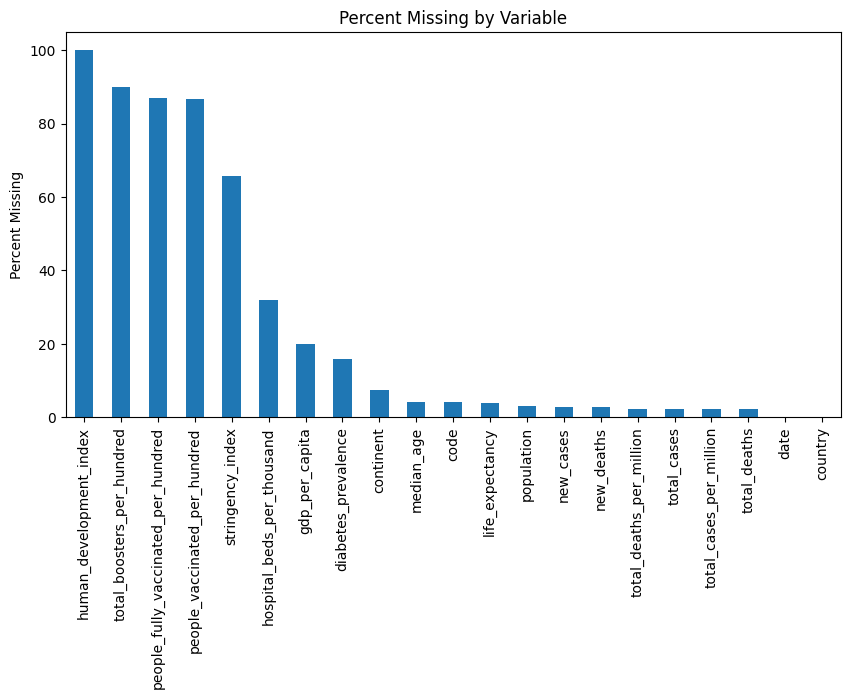

In [12]:
missing_pct.plot(kind="bar", figsize=(10,5))
plt.title("Percent Missing by Variable")
plt.ylabel("Percent Missing")
plt.show()


### Missing Value Assessment

The missing value analysis reveals substantial variation in data completeness across variables.

The Human Development Index variable is completely missing and will be removed from further analysis. Vaccination-related variables exhibit the highest levels of missingness, with more than 85% of observations lacking vaccination or booster information. This is expected because vaccinations were introduced later in the pandemic and reporting varied across countries.

Economic and healthcare variables such as GDP per capita, diabetes prevalence, and hospital beds per thousand also contain missing values, though they remain available for a majority of observations.

COVID-19 case and mortality variables are relatively complete, with approximately 98% coverage. Demographic variables such as median age and life expectancy are also highly complete.

Because the dataset contains daily observations, some variables that appear sparse at the row level may become substantially more complete after aggregation to the country level. Additional assessment will be performed after creating country-level summary data.

In [13]:
owid_small = owid_small.drop(columns=["human_development_index"])

In [14]:
owid_small.shape

(591522, 20)

## Duplicate Records

Duplicate observations can create bias during analysis and should be identified before further processing.

In [15]:
owid_small.duplicated().sum()

np.int64(0)

In [16]:
country_date_dups = (
    owid_small
    .duplicated(subset=["country", "date"])
    .sum()
)

print(country_date_dups)

0


### Duplicate Record Assessment

No duplicate records were identified in the reduced dataset. In addition, no duplicate country-date combinations were found, indicating that each observation represents a unique country-date record.

Because the data appear to be uniquely indexed by country and date, duplicate removal is not required at this stage of the analysis.

## Date Variable

The date variable is currently stored as a character string. Converting it to a datetime format will facilitate time-based analysis and validation of the dataset.

In [17]:
owid_small["date"] = pd.to_datetime(owid_small["date"])

In [18]:
owid_small["date"].describe()

count                           591522
mean     2023-03-01 14:42:40.865022720
min                2020-01-01 00:00:00
25%                2021-07-30 00:00:00
50%                2023-02-22 00:00:00
75%                2024-10-01 00:00:00
max                2026-05-17 00:00:00
Name: date, dtype: object

## Country Coverage

Before merging additional datasets, I will examine the geographic coverage of the OWID dataset and identify any aggregate regions or non-country entities that may require special handling.

In [19]:
owid_small["country"].nunique()

262

In [20]:
owid_small["continent"].value_counts(dropna=False)

continent
Africa           131550
Europe           118806
Asia             113720
North America     95435
Oceania           55851
NaN               43560
South America     32600
Name: count, dtype: int64

In [21]:
owid_small.loc[
    owid_small["continent"].isna(),
    "country"
].unique()

array(['Africa', 'Asia', 'Asia excl. China', 'England',
       'England and Wales', 'Europe', 'European Union (27)',
       'High-income countries', 'Low-income countries',
       'Lower-middle-income countries', 'North America',
       'Northern Ireland', 'Oceania', 'Scotland', 'South America',
       'Summer Olympics 2020', 'Upper-middle-income countries', 'Wales',
       'Winter Olympics 2022', 'World', 'World excl. China',
       'World excl. China and South Korea',
       'World excl. China, South Korea, Japan and Singapore'],
      dtype=object)

### Non-Country Geographic Entities

Inspection of records with missing continent values revealed several aggregate geographic regions, economic classifications, and special entities. Examples include World, European Union (27), High-income countries, and Lower-middle-income countries. The dataset also contains observations for England, Scotland, Wales, and Northern Ireland, which are not sovereign countries but may appear separately in COVID reporting systems.

Because the objective of this project is to analyze country-level mortality outcomes, these aggregate and special entities will be excluded from the final analytical dataset. The continent variable provides a convenient mechanism for identifying many of these records because aggregate entities typically have missing continent values.

In [22]:
owid_country = owid_small[
    owid_small["continent"].notna()
].copy()

In [23]:
owid_country["country"].nunique()


239

In [24]:
owid_country.shape


(547962, 20)

In [25]:
owid_country["continent"].isna().sum()

np.int64(0)

### Country-Level Dataset

To align the dataset with the project objective, observations representing aggregate regions, income groups, and special entities were removed. Records with non-missing continent values were retained, resulting in a dataset focused on individual countries and territories.

The filtered dataset will be used for subsequent analysis and integration with external demographic, economic, and policy datasets.

## Create a Country-Level Analytical Dataset

The OWID dataset contains daily observations for each country. Since the objective of this project is to compare mortality outcomes across countries, I will create a country-level summary dataset.

For cumulative measures such as total cases, total deaths, vaccination coverage, and booster coverage, the maximum observed value for each country will be used. Demographic and economic variables are generally constant within countries and will also be summarized using their maximum observed value.

### Government Response Measures

The OWID dataset includes the Oxford COVID Government Response Tracker Stringency Index, which summarizes the severity of public health interventions such as school closures, workplace restrictions, and travel limitations.

Because the Stringency Index varies over time, the mean value across the observation period will be used to represent the overall intensity of government response for each country.

In [26]:
owid_country_summary = (
    owid_country
    .groupby(
        ["country", "code", "continent"],
        as_index=False
    )
    .agg(
        population=("population", "max"),

        total_cases=("total_cases", "max"),
        total_cases_per_million=("total_cases_per_million", "max"),

        total_deaths=("total_deaths", "max"),
        total_deaths_per_million=("total_deaths_per_million", "max"),

        people_vaccinated_per_hundred=(
            "people_vaccinated_per_hundred",
            "max"
        ),

        people_fully_vaccinated_per_hundred=(
            "people_fully_vaccinated_per_hundred",
            "max"
        ),

        total_boosters_per_hundred=(
            "total_boosters_per_hundred",
            "max"
        ),

        stringency_index=("stringency_index", "mean"),

        median_age=("median_age", "max"),
        gdp_per_capita=("gdp_per_capita", "max"),
        hospital_beds_per_thousand=("hospital_beds_per_thousand", "max"),
        life_expectancy=("life_expectancy", "max"),
        diabetes_prevalence=("diabetes_prevalence", "max")
    )
)

In [27]:
owid_country_summary.head()

,country,code,continent,population,total_cases,total_cases_per_million,total_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence
0,Afghanistan,AFG,Asia,40578847.0,235214.0,5796.4683,7998.0,197.09776,47.195450,45.270844,6.727495,27.394580,16.752001,1983.812622,0.35,65.616997,11.7
1,Albania,ALB,Europe,2827614.0,337234.0,119264.5100,3608.0,1275.98740,47.717087,45.244260,14.230054,41.782108,35.943001,21641.074219,2.90,78.768799,10.6
2,Algeria,DZA,Africa,45477391.0,272440.0,5990.6690,6881.0,151.30595,17.239624,14.251447,1.265796,48.367728,27.983000,15501.919922,1.61,76.128899,17.5
3,American Samoa,ASM,Oceania,48365.0,8359.0,172831.6000,34.0,702.98770,NaN,NaN,NaN,NaN,27.927000,NaN,NaN,72.752098,NaN
4,Andorra,AND,Europe,79722.0,48015.0,602280.4400,159.0,1994.43070,72.643684,67.109460,54.026493,33.486770,42.832001,65928.304688,NaN,84.016403,10.1


In [28]:
owid_country_summary.shape


(239, 17)

### Validation of Country-Level Dataset

The country-level dataset should contain one record per country. The number of rows should therefore be approximately equal to the number of countries represented in the filtered dataset.

In [29]:
owid_country_summary["country"].nunique()

239

In [30]:
owid_country_summary.duplicated(
    subset=["country"]
).sum()

np.int64(0)

### Missing Values After Aggregation

Many variables that appeared sparse in the daily dataset may become substantially more complete after aggregation to the country level. Missingness will therefore be reassessed.

In [31]:
country_missing = (
    owid_country_summary
    .isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

country_missing

hospital_beds_per_thousand             29.707113
stringency_index                       22.594142
gdp_per_capita                         16.736402
total_boosters_per_hundred             12.970711
diabetes_prevalence                    12.552301
people_fully_vaccinated_per_hundred    10.041841
people_vaccinated_per_hundred           9.205021
total_deaths                            2.510460
total_cases                             2.510460
total_deaths_per_million                2.510460
total_cases_per_million                 2.510460
median_age                              0.836820
population                              0.836820
life_expectancy                         0.836820
country                                 0.000000
continent                               0.000000
code                                    0.000000
dtype: float64

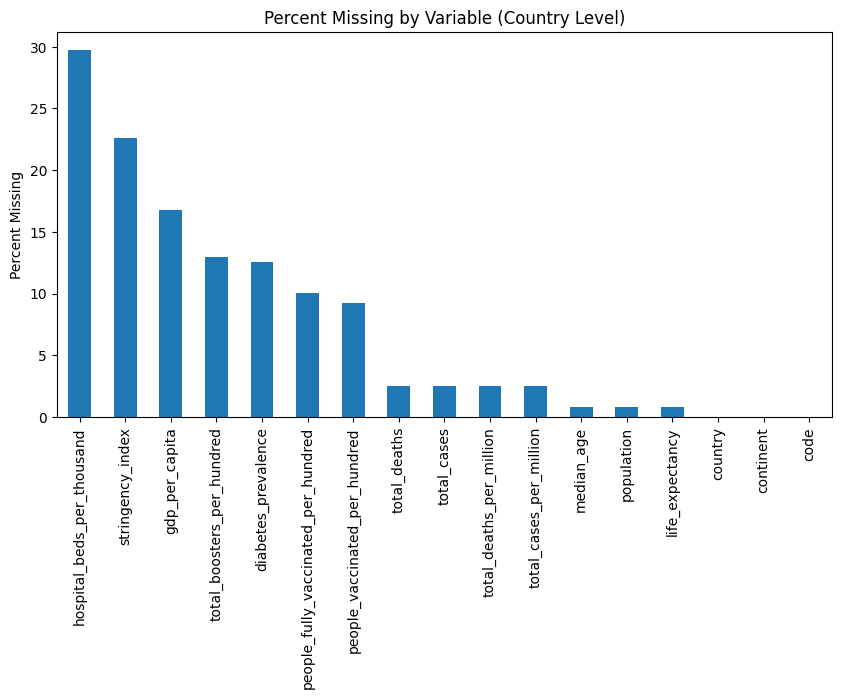

In [32]:
country_missing.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Percent Missing by Variable (Country Level)")
plt.ylabel("Percent Missing")
plt.show()

### Initial Country-Level Observations

Aggregating the data to the country level substantially reduces the number of observations and provides a dataset that is more suitable for exploratory analysis and predictive modeling. Missingness in vaccination variables is expected to decrease because the maximum observed value is used rather than individual daily observations.

The resulting dataset contains mortality outcomes, vaccination coverage measures, demographic indicators, economic variables, and healthcare resource measures for each country.

### Missing Values After Aggregation

Aggregating the data from daily observations to a single record per country substantially improved data completeness. Vaccination variables that appeared highly sparse in the daily dataset became much more complete after selecting the maximum observed value for each country.

Most variables now have less than 15% missing data. The largest remaining sources of missingness are hospital beds per thousand (29.7%), GDP per capita (16.7%), booster coverage (13.0%), and diabetes prevalence (12.6%).

COVID-19 case and mortality measures are available for nearly all countries, while demographic variables such as median age and life expectancy are available for more than 99% of countries.

These results suggest that the country-level dataset is suitable for exploratory analysis and that only limited additional handling of missing values may be required during modeling.

In [33]:
owid_country_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
population,237.0,3.384130e+07,1.364037e+08,513.000000,397542.000000,5.456796e+06,2.250904e+07,1.425423e+09
total_cases,233.0,3.344073e+06,1.146156e+07,0.000000,25292.000000,1.914960e+05,1.279115e+06,1.034368e+08
total_cases_per_million,233.0,2.083471e+05,2.059958e+05,0.000000,20186.773000,1.355382e+05,3.510781e+05,7.698068e+05
total_deaths,233.0,3.054047e+04,1.096326e+05,0.000000,172.000000,1.937000e+03,1.412200e+04,1.238189e+06
total_deaths_per_million,233.0,1.276360e+03,1.338187e+03,0.000000,141.097660,8.893516e+02,2.023351e+03,6.603977e+03
people_vaccinated_per_hundred,217.0,6.261500e+01,2.414233e+01,0.277072,44.640140,6.808708e+01,8.047407e+01,1.120751e+02
people_fully_vaccinated_per_hundred,215.0,5.710050e+01,2.443564e+01,0.272658,39.363430,6.244032e+01,7.592957e+01,1.101884e+02
total_boosters_per_hundred,208.0,3.445340e+01,3.111692e+01,0.000000,7.718700,2.841672e+01,5.628939e+01,1.405325e+02
stringency_index,185.0,4.267543e+01,9.638693e+00,11.333896,36.689361,4.327304e+01,4.919622e+01,7.331321e+01
median_age,237.0,3.120876e+01,9.735554e+00,14.298000,22.243999,3.169800e+01,3.908000e+01,5.987500e+01


### Country-Level Dataset

The daily OWID observations were aggregated to the country level to create a single analytical record per country. Cumulative measures such as cases, deaths, and vaccination coverage were summarized using their maximum values, while the Stringency Index was summarized using its mean value over time.

This approach preserves the final pandemic outcomes while capturing the average level of government response experienced by each country.

### Descriptive Statistics

Summary statistics indicate substantial variation across countries in both COVID-19 outcomes and potential predictor variables.

The median country experienced approximately 192,000 cumulative COVID-19 cases and 1,937 cumulative deaths, although the distributions are highly skewed due to the large differences in country population sizes. For this reason, per-capita measures such as cases per million and deaths per million may be more appropriate outcome variables for comparative analysis.

Vaccination coverage also varies considerably across countries. The median country achieved approximately 68% vaccination coverage and 62% full vaccination coverage, while booster uptake shows even greater variability.

Demographic and economic variables exhibit substantial diversity across countries, with median age ranging from approximately 14 to 60 years and GDP per capita ranging from approximately $1,000 to over $130,000. This variation suggests that the dataset contains sufficient heterogeneity to support exploratory analysis and predictive modeling.

In [34]:
owid_country_summary.sort_values(
    "total_deaths_per_million",
    ascending=False
)[
    ["country",
     "population",
     "total_deaths_per_million"]
].head(15)


,country,population,total_deaths_per_million
166,Peru,33475436.0,6603.9766
31,Bulgaria,6825862.0,5681.0405
156,North Macedonia,1840236.0,5429.1950
26,Bosnia and Herzegovina,3204802.0,5123.2495
94,Hungary,9684308.0,5072.5360
49,Croatia,3907031.0,4813.1177
195,Slovenia,2115231.0,4686.9585
77,Georgia,3794782.0,4519.6274
140,Montenegro,614649.0,4317.9116
53,Czechia,10673216.0,4116.0040


### Review of Highest Mortality Countries

Countries with the highest reported cumulative COVID-19 mortality rates include Peru, Bulgaria, North Macedonia, Bosnia and Herzegovina, Hungary, and Croatia. These results are broadly consistent with reports from the pandemic period and provide confidence that the mortality variable has been aggregated correctly.

A small number of countries and territories with relatively small populations also appear among the highest mortality rates. Because mortality rates in very small populations can be highly sensitive to small changes in case counts and reporting practices, population-based filtering may be considered during later stages of the analysis.

# 7. Summary of OWID Data Wrangling

The OWID dataset was successfully acquired, inspected, cleaned, and aggregated from daily observations to a country-level analytical dataset. Aggregate geographic entities such as World and income groups were removed, duplicate country-date records were not identified, and missing values were assessed both before and after aggregation.

The resulting dataset contains 239 countries and territories along with COVID-19 outcomes, vaccination measures, demographic indicators, and healthcare-related variables. This dataset will serve as the foundation for integration with additional economic and policy datasets.

## Save Intermediate Dataset

The country-level OWID dataset represents a significant data wrangling milestone. Saving an intermediate version allows the dataset to be reused in later notebook sections and provides a reproducible checkpoint before integrating additional external data sources.


In [35]:
owid_country_summary.to_csv(
    "../data/interim/owid_country_summary.csv",
    index=False
)


In [36]:
os.path.exists("../data/interim/owid_country_summary.csv")

True

In [37]:
saved_df = pd.read_csv(
    "../data/interim/owid_country_summary.csv"
)

saved_df.shape

(239, 17)

In [38]:
owid.to_csv(
    "../data/raw/owid_covid_raw.csv",
    index=False
)

# Selected variables
owid_small.to_csv(
    "../data/interim/owid_selected_variables.csv",
    index=False
)


In [39]:
os.path.exists("../data/raw/owid_covid_raw.csv")

True

In [40]:
os.path.exists("../data/interim/owid_selected_variables.csv")

True

# 8. Continue from Saved OWID Dataset

The previous sections of this notebook focused on acquiring, cleaning, validating, and aggregating the Our World in Data (OWID) COVID-19 dataset. The resulting country-level dataset was saved as an intermediate file to improve reproducibility and provide a checkpoint before integrating additional data sources.

In this section, I will reload the saved country-level dataset and use it as the starting point for incorporating external economic and policy data. Working from a saved intermediate dataset reduces computational overhead and ensures that subsequent analyses are based on a consistent version of the data.

The next step is to load the saved country-level dataset and verify its structure before proceeding with additional data collection and merging.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import requests

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

owid_country_summary = pd.read_csv(
    "../data/interim/owid_country_summary.csv"
)

print(f"Rows: {owid_country_summary.shape[0]}")
print(f"Columns: {owid_country_summary.shape[1]}")

owid_country_summary.head()

Rows: 239
Columns: 17


,country,code,continent,population,total_cases,total_cases_per_million,total_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence
0,Afghanistan,AFG,Asia,40578847.0,235214.0,5796.4683,7998.0,197.09776,47.195450,45.270844,6.727495,27.394580,16.752001,1983.812622,0.35,65.616997,11.7
1,Albania,ALB,Europe,2827614.0,337234.0,119264.5100,3608.0,1275.98740,47.717087,45.244260,14.230054,41.782108,35.943001,21641.074219,2.90,78.768799,10.6
2,Algeria,DZA,Africa,45477391.0,272440.0,5990.6690,6881.0,151.30595,17.239624,14.251447,1.265796,48.367728,27.983000,15501.919922,1.61,76.128899,17.5
3,American Samoa,ASM,Oceania,48365.0,8359.0,172831.6000,34.0,702.98770,NaN,NaN,NaN,NaN,27.927000,NaN,NaN,72.752098,NaN
4,Andorra,AND,Europe,79722.0,48015.0,602280.4400,159.0,1994.43070,72.643684,67.109460,54.026493,33.486770,42.832001,65928.304688,NaN,84.016403,10.1


In [42]:
owid_country_summary.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              239 non-null    object 
 1   code                                 239 non-null    object 
 2   continent                            239 non-null    object 
 3   population                           237 non-null    float64
 4   total_cases                          233 non-null    float64
 5   total_cases_per_million              233 non-null    float64
 6   total_deaths                         233 non-null    float64
 7   total_deaths_per_million             233 non-null    float64
 8   people_vaccinated_per_hundred        217 non-null    float64
 9   people_fully_vaccinated_per_hundred  215 non-null    float64
 10  total_boosters_per_hundred           208 non-null    float64
 11  stringency_index                

In [43]:
owid_country_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
population,237.0,3.384130e+07,1.364037e+08,513.000000,397542.000000,5.456796e+06,2.250904e+07,1.425423e+09
total_cases,233.0,3.344073e+06,1.146156e+07,0.000000,25292.000000,1.914960e+05,1.279115e+06,1.034368e+08
total_cases_per_million,233.0,2.083471e+05,2.059958e+05,0.000000,20186.773000,1.355382e+05,3.510781e+05,7.698068e+05
total_deaths,233.0,3.054047e+04,1.096326e+05,0.000000,172.000000,1.937000e+03,1.412200e+04,1.238189e+06
total_deaths_per_million,233.0,1.276360e+03,1.338187e+03,0.000000,141.097660,8.893516e+02,2.023351e+03,6.603977e+03
people_vaccinated_per_hundred,217.0,6.261500e+01,2.414233e+01,0.277072,44.640140,6.808708e+01,8.047407e+01,1.120751e+02
people_fully_vaccinated_per_hundred,215.0,5.710050e+01,2.443564e+01,0.272658,39.363430,6.244032e+01,7.592957e+01,1.101884e+02
total_boosters_per_hundred,208.0,3.445340e+01,3.111692e+01,0.000000,7.718700,2.841672e+01,5.628939e+01,1.405325e+02
stringency_index,185.0,4.267543e+01,9.638693e+00,11.333896,36.689361,4.327304e+01,4.919622e+01,7.331321e+01
median_age,237.0,3.120876e+01,9.735554e+00,14.298000,22.243999,3.169800e+01,3.908000e+01,5.987500e+01


# 9. World Bank Data Collection and Wrangling

The OWID dataset already contains several demographic and economic variables, but World Bank Open Data can provide additional country-level indicators that may be useful during exploratory analysis and modeling.

For this project, I will collect a small set of World Bank indicators related to population density and healthcare spending. These variables may help explain differences in COVID-19 mortality across countries.

In [44]:


def get_world_bank_indicator(indicator, indicator_name, date="2021"):
    """
    Download one World Bank indicator for all countries for a selected year.
    Returns a clean dataframe with ISO-3 country code and indicator value.
    """
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
        f"?format=json&per_page=20000&date={date}"
    )
    
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()[1]
    
    df = pd.DataFrame(data)
    
    df_clean = pd.DataFrame({
        "iso_code": df["countryiso3code"],
        "country_wb": df["country"].apply(lambda x: x["value"]),
        indicator_name: df["value"]
    })
    
    df_clean = df_clean[df_clean["iso_code"] != ""]
    
    return df_clean

## Select World Bank Indicators

I will begin with three indicators:

- Population density
- Current health expenditure per capita
- Current health expenditure as a percent of GDP

These indicators may provide additional context about population concentration and healthcare system resources.

In [45]:
wb_pop_density = get_world_bank_indicator(
    "EN.POP.DNST",
    "population_density",
    date="2021"
)

wb_health_exp_pc = get_world_bank_indicator(
    "SH.XPD.CHEX.PC.CD",
    "health_expenditure_per_capita",
    date="2021"
)

wb_health_exp_gdp = get_world_bank_indicator(
    "SH.XPD.CHEX.GD.ZS",
    "health_expenditure_pct_gdp",
    date="2021"
)

In [46]:
wb_pop_density.head()

,iso_code,country_wb,population_density
0,AFE,Africa Eastern and Southern,48.035473
1,AFW,Africa Western and Central,53.718018
2,ARB,Arab World,35.162362
3,CSS,Caribbean small states,11.239289
4,CEB,Central Europe and the Baltics,90.687759


## Inspect World Bank Data

The World Bank dataset contains both individual countries and aggregate regional entities. Because this project focuses on country-level analysis, aggregate entities will be removed prior to merging.

The ISO-3 country code will be used as the primary merge key between datasets.

## Combine World Bank Indicators

Three World Bank indicators were downloaded separately. Before merging them with the OWID dataset, they will be combined into a single World Bank dataset using the ISO-3 country code as the key.

Combining these indicators first simplifies validation and creates a reusable intermediate dataset.

In [47]:
wb = (
    wb_pop_density
    .merge(
        wb_health_exp_pc,
        on=["iso_code", "country_wb"],
        how="outer"
    )
    .merge(
        wb_health_exp_gdp,
        on=["iso_code", "country_wb"],
        how="outer"
    )
)

### Validate Combined World Bank Dataset

Before merging with the OWID dataset, I will examine the structure, completeness, and uniqueness of the World Bank indicators.

In [48]:
wb.shape

(261, 5)

In [49]:
wb.head()

,iso_code,country_wb,population_density,health_expenditure_per_capita,health_expenditure_pct_gdp
0,ABW,Aruba,598.333333,NaN,NaN
1,AFE,Africa Eastern and Southern,48.035473,92.350333,5.942595
2,AFG,Afghanistan,61.328691,81.521126,21.508444
3,AFW,Africa Western and Central,53.718018,72.632850,4.135622
4,AGO,Angola,27.699069,66.944870,2.739871


In [50]:
wb.info()

# %%
wb_missing = (
    wb.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

wb_missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   iso_code                       261 non-null    object 
 1   country_wb                     261 non-null    object 
 2   population_density             260 non-null    float64
 3   health_expenditure_per_capita  236 non-null    float64
 4   health_expenditure_pct_gdp     237 non-null    float64
dtypes: float64(3), object(2)
memory usage: 10.3+ KB


health_expenditure_per_capita    9.578544
health_expenditure_pct_gdp       9.195402
population_density               0.383142
iso_code                         0.000000
country_wb                       0.000000
dtype: float64

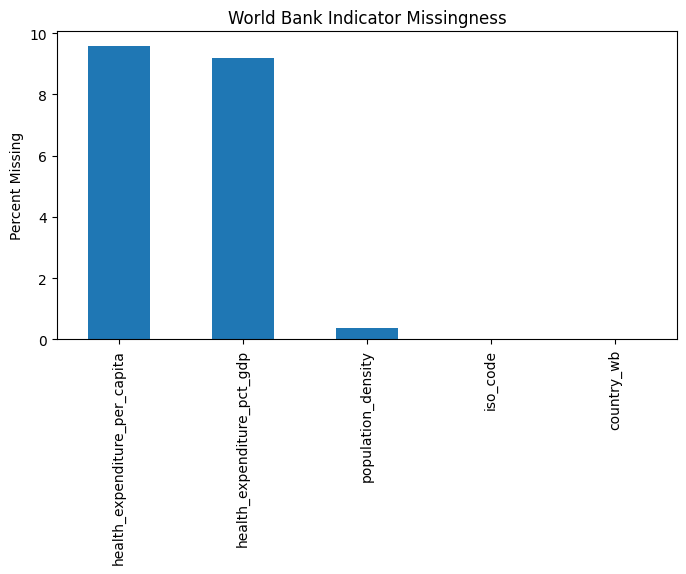

In [51]:
wb_missing.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("World Bank Indicator Missingness")
plt.ylabel("Percent Missing")
plt.show()

In [52]:
wb.isna().sum()

iso_code                          0
country_wb                        0
population_density                1
health_expenditure_per_capita    25
health_expenditure_pct_gdp       24
dtype: int64

### Assessment of World Bank Data Quality

The three World Bank indicators were successfully combined into a single dataset containing 261 records and five variables. No duplicate ISO-3 country codes were identified, indicating that each record represents a unique country or reporting entity.

Data completeness was generally high. Population density was available for nearly all records, with only one missing value. Healthcare expenditure indicators were available for approximately 90% of countries, with 24–25 missing values depending on the measure.

Given the low level of missingness and the absence of duplicate country identifiers, the World Bank dataset appears suitable for integration with the country-level COVID dataset. Any remaining missing values will be assessed again after merging with the OWID data.

In [53]:
wb["iso_code"].duplicated().sum()

np.int64(0)

### Save World Bank Dataset

The three World Bank indicators have now been combined into a single dataset. Saving this intermediate file provides a reproducible checkpoint and allows later notebook sections to begin without repeating the download and merge process.

In [54]:
wb.to_csv(
    "../data/interim/worldbank_indicators.csv",
    index=False
)

### Restart here....

In [55]:
wb = pd.read_csv(
    "../data/interim/worldbank_indicators.csv"
)

wb.head()

,iso_code,country_wb,population_density,health_expenditure_per_capita,health_expenditure_pct_gdp
0,ABW,Aruba,598.333333,NaN,NaN
1,AFE,Africa Eastern and Southern,48.035473,92.350333,5.942595
2,AFG,Afghanistan,61.328691,81.521126,21.508444
3,AFW,Africa Western and Central,53.718018,72.632850,4.135622
4,AGO,Angola,27.699069,66.944870,2.739871


In [56]:
covid_worldbank = owid_country_summary.merge(
    wb,
    left_on="code",
    right_on="iso_code",
    how="left"
)

In [57]:
covid_worldbank.shape

(239, 22)

In [58]:
covid_worldbank.head

<bound method NDFrame.head of                country code continent  population  total_cases  \
0          Afghanistan  AFG      Asia  40578847.0     235214.0   
1              Albania  ALB    Europe   2827614.0     337234.0   
2              Algeria  DZA    Africa  45477391.0     272440.0   
3       American Samoa  ASM   Oceania     48365.0       8359.0   
4              Andorra  AND    Europe     79722.0      48015.0   
..                 ...  ...       ...         ...          ...   
234  Wallis and Futuna  WLF   Oceania     11501.0       3760.0   
235     Western Sahara  ESH    Africa    568746.0          NaN   
236              Yemen  YEM      Asia  38222878.0      11945.0   
237             Zambia  ZMB    Africa  20152935.0     349892.0   
238           Zimbabwe  ZWE    Africa  16069061.0     266436.0   

     total_cases_per_million  total_deaths  total_deaths_per_million  \
0                  5796.4683        7998.0                197.097760   
1                119264.5100     

# Final Analytical Dataset

The final analytical dataset combines country-level COVID outcomes, vaccination coverage, government response measures, demographic characteristics, economic indicators, healthcare resources, and population density.

The resulting dataset contains one record per country and will serve as the primary input for exploratory data analysis and predictive modeling in the next phase of the project.

In [59]:
covid_worldbank.to_csv(
    "../data/processed/covid_analysis_dataset.csv",
    index=False
)

### Assessment of World Bank Indicators

The World Bank merge was largely successful. Population density data were available for approximately 90% of countries, while healthcare expenditure indicators were available for approximately 81% of countries.

Most missing values appear to be associated with small territories or regions that are not fully represented in World Bank reporting systems. Because the majority of countries were successfully matched, the merged dataset provides useful additional context for subsequent analysis.

In [60]:
covid_worldbank_check = pd.read_csv(
     "../data/processed/covid_analysis_dataset.csv",
)

covid_worldbank_check.shape

(239, 22)